# Raport: Drzewa decyzyjne, Random Forest i k-NN

## Import bibliotek i ustawienia globalne

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import graphviz
import dtreeviz
import shap
import warnings
import optuna
from sklearn.compose import ColumnTransformer
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import f1_score, accuracy_score
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_graphviz

seed = 42
np.random.seed(seed)

warnings.filterwarnings("ignore", category=FutureWarning)

# Część I: Drzewa decyzyjne

## 1. Zbiór Adult Census Income — eksploracyjna analiza danych

### 1.1. Wczytanie danych

In [2]:
dataset_name = "Adult Census Income"
ds = fetch_openml("adult",as_frame=True, parser="auto",  version=2)
df = ds.frame.copy()

df['income'] = (df['class'] == '>50K').astype(int)
df = df.drop(columns=['class'])
target_col ="income"
print(f'Wczytano {dataset_name}: {df.shape}')
print(f'Rozkład klas {df[target_col].value_counts().to_dict()} '
      f'basline = {df[target_col].mean():.3f}'
      )
df.head()

Wczytano Adult Census Income: (48842, 15)
Rozkład klas {0: 37155, 1: 11687} basline = 0.239


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,0
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,0
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,1
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,1
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,0


### 1.2. Typy zmiennych i braki danych

In [3]:
info = pd.DataFrame(
      {
            'dtypes': df.dtypes.astype(str),
            'missing': df.isnull().sum(),
            "missing %": (df.isnull().sum() / len(df) * 100).round(2),
            "nunique": df.nunique()
      }
)
info

,dtypes,missing,missing %,nunique
age,int64,0,0.00,74
workclass,category,2799,5.73,8
fnlwgt,int64,0,0.00,28523
education,category,0,0.00,16
education-num,int64,0,0.00,16
marital-status,category,0,0.00,7
occupation,category,2809,5.75,14
relationship,category,0,0.00,6
race,category,0,0.00,5
sex,category,0,0.00,2


### 1.3. Podział cech na numeryczne i kategoryczne

In [4]:
num_cols = df.select_dtypes(include=[np.number]).columns.drop(target_col).tolist()
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print(f'Numeric: ({len(num_cols)}): {num_cols}')
print(f'Categorical: ({len(cat_cols)}): {cat_cols}')

Numeric: (6): ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Categorical: (8): ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


In [5]:
df[num_cols].describe().round(2)

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.00,48842.00,48842.00,48842.00,48842.0,48842.00
mean,38.64,189664.13,10.08,1079.07,87.5,40.42
std,13.71,105604.03,2.57,7452.02,403.0,12.39
min,17.00,12285.00,1.00,0.00,0.0,1.00
25%,28.00,117550.50,9.00,0.00,0.0,40.00
50%,37.00,178144.50,10.00,0.00,0.0,40.00
75%,48.00,237642.00,12.00,0.00,0.0,45.00
max,90.00,1490400.00,16.00,99999.00,4356.0,99.00


### 1.4. Zależność P(target = 1 | cecha) dla cech kategorycznych

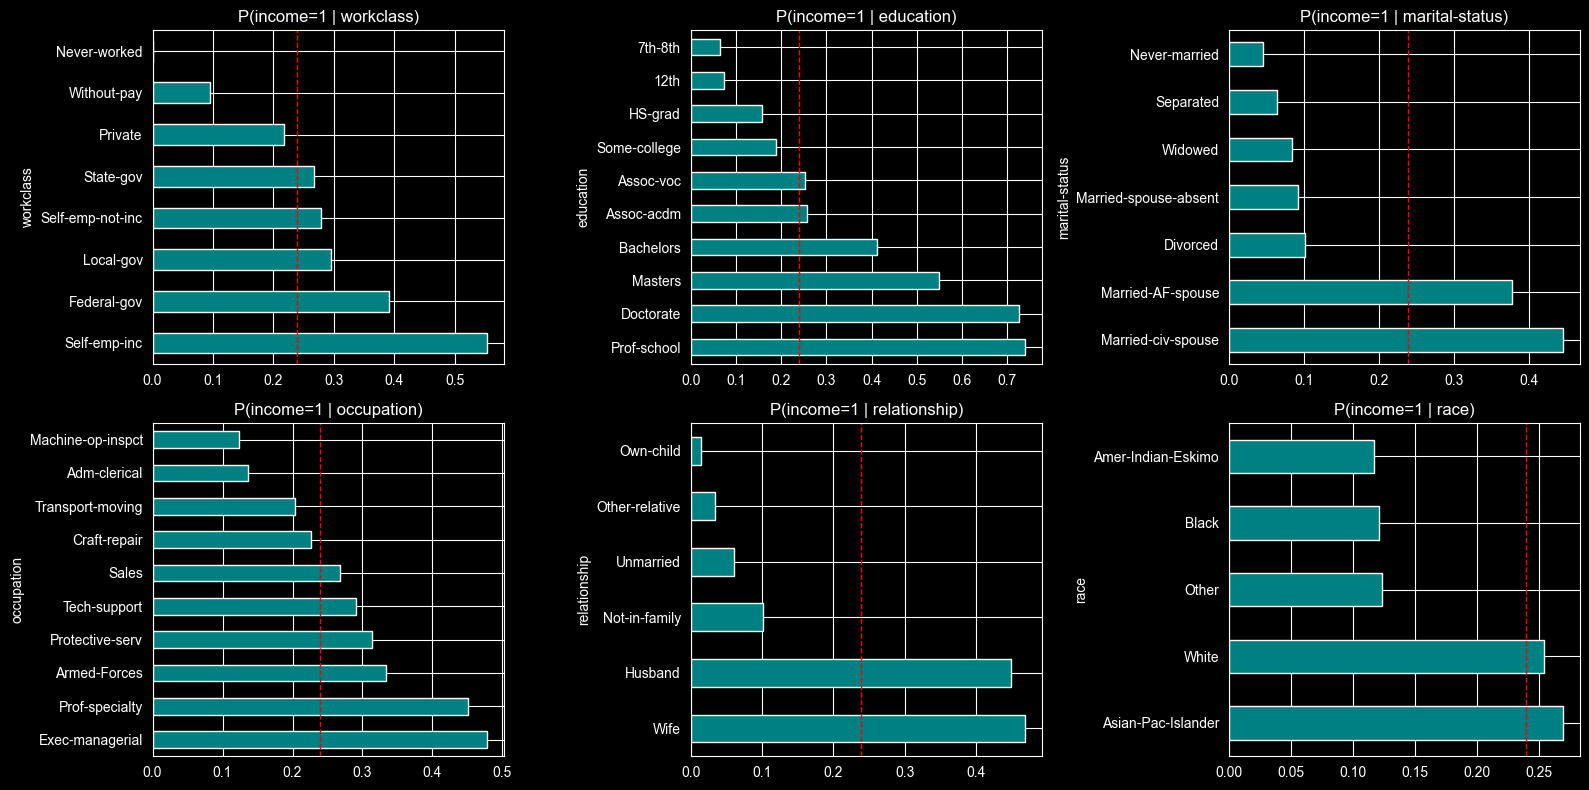

In [6]:
if cat_cols:
      fig, axes = plt.subplots(2, min(3, len(cat_cols)), figsize=(16, 8))

      axes = np.array(axes).ravel()

      for i, c in enumerate(cat_cols[:6]):
            vc = df.groupby(c)[target_col].mean().sort_values(ascending=False).head(10)
            vc.plot(kind='barh', ax=axes[i], color='teal')
            axes[i].axvline(df[target_col].mean(), color='red', ls='--', lw=1)
            axes[i].set_title(f'P({target_col}=1 | {c})')
            axes[i].set_xlabel('')

      plt.tight_layout()
      plt.show()

---

## 2. Preprocessing danych

### 2.1. Pipeline preprocessingu

In [7]:
numeric_transformer = Pipeline(
      [("imputer", SimpleImputer(strategy="median"))]
)
categorical_transformer = Pipeline(
       [
             ("imputer", SimpleImputer(strategy="most_frequent")),
             ("encoder", OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
       ]
)

preproc = ColumnTransformer(
      [
            ("num", numeric_transformer, num_cols),
            ("cat", categorical_transformer, cat_cols)

      ],
      remainder='drop'
)

feature_name = num_cols + cat_cols

X = df.drop(columns=target_col)
y = df[target_col].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
      X, y, test_size=0.25, stratify=y, random_state=seed
)

print(f'Trening: {X_train.shape} Test: {X_test.shape}')
print(f'Rozkład klas (trening): {pd.Series(y_train).value_counts(normalize=True).round(3).to_dict()}')

Trening: (36631, 14) Test: (12211, 14)
Rozkład klas (trening): {0: 0.761, 1: 0.239}


---

## 3. Pełne drzewo decyzyjne

### 3.1. Trening drzewa bez regularyzacji, głębokość, liczba liści oraz train vs test accuracy

In [8]:
base_pipe  = Pipeline(
      [
            ('preproc', preproc),
            ('clf', DecisionTreeClassifier(random_state=seed))
      ]
)

base_pipe.fit(X_train, y_train)

print(f'Pełne drzewo: głębokość: ({base_pipe['clf'].get_depth()}) '
      f'liście: ({base_pipe['clf'].get_n_leaves()})'
      )
print(f'Trening accuracy: {base_pipe.score(X_train, y_train) :.4f}')
print(f'Test accuracy: {base_pipe.score(X_test, y_test) :.4f}')

Pełne drzewo: głębokość: (44) liście: (5440)
Trening accuracy: 0.9999
Test accuracy: 0.8175


## 4. Dobór głębokości drzewa metodą walidacji krzyżowej

### 4.1 Walidacja krzyżowa dla max_depth ∈ {1, ..., 20}

In [9]:
grid_cv = GridSearchCV(
      base_pipe,
      cv=10,
      param_grid={'clf__max_depth': range(1, 21)},
      return_train_score=True,
      scoring="accuracy",
      n_jobs=-1)

grid_cv.fit(X_train, y_train)
best_max_depth = grid_cv.best_params_['clf__max_depth']
print("Best depth:", best_max_depth)
print("Best CV score:", grid_cv.best_score_)



Best depth: 7
Best CV score: 0.8541671509739196


### 4.2. Krzywa bias-variance

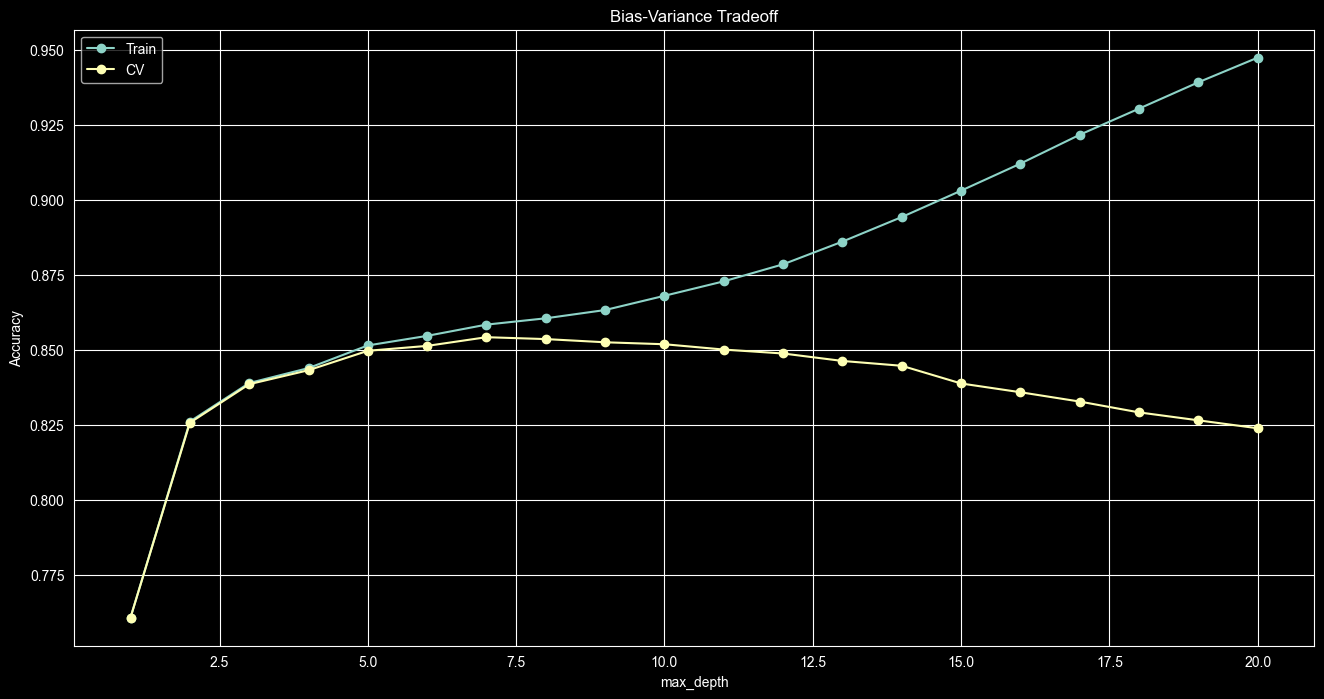

In [10]:
depths = range(1, 21)
train_scores = grid_cv.cv_results_['mean_train_score']
val_scores = grid_cv.cv_results_['mean_test_score']

plt.figure(figsize=(16, 8))

plt.plot(depths, train_scores, marker='o', label='Train')
plt.plot(depths, val_scores, marker='o', label='CV')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Bias-Variance Tradeoff')
plt.legend()
plt.grid(True)
plt.show()

---

## 5. Cost-Complexity Pruning

### 5.1. Ścieżka przycinania `ccp_alpha`

In [11]:
X_train_transformed = preproc.fit_transform(X_train)
clf = DecisionTreeClassifier(random_state=seed)

path = clf.cost_complexity_pruning_path(X_train_transformed, y_train)
print(f'{path.ccp_alphas=}')

path.ccp_alphas=array([0.00000000e+00, 9.09976068e-06, 9.09976068e-06, ...,
       2.00675099e-02, 2.50913902e-02, 5.98701925e-02], shape=(1993,))


### 5.2. Budowa tabeli wyników dla ścieżki CCP

In [50]:
rows = []

for a in path.ccp_alphas:
    pipe = Pipeline([
        ('preproc', preproc),
        ('clf', DecisionTreeClassifier(random_state=seed, ccp_alpha=a))
    ])

    pipe.fit(X_train, y_train)

    rows.append({
        'ccp_alpha': a,
        'depth': pipe['clf'].get_depth(),
        'n_leaves': pipe['clf'].get_n_leaves(),
        'train_acc': pipe.score(X_train, y_train),
        'test_acc': pipe.score(X_test, y_test)
    })

cost_complexity_df = pd.DataFrame(rows)

### 5.3. Wizualizacja wpływu `ccp_alpha` na jakość i złożoność drzewa

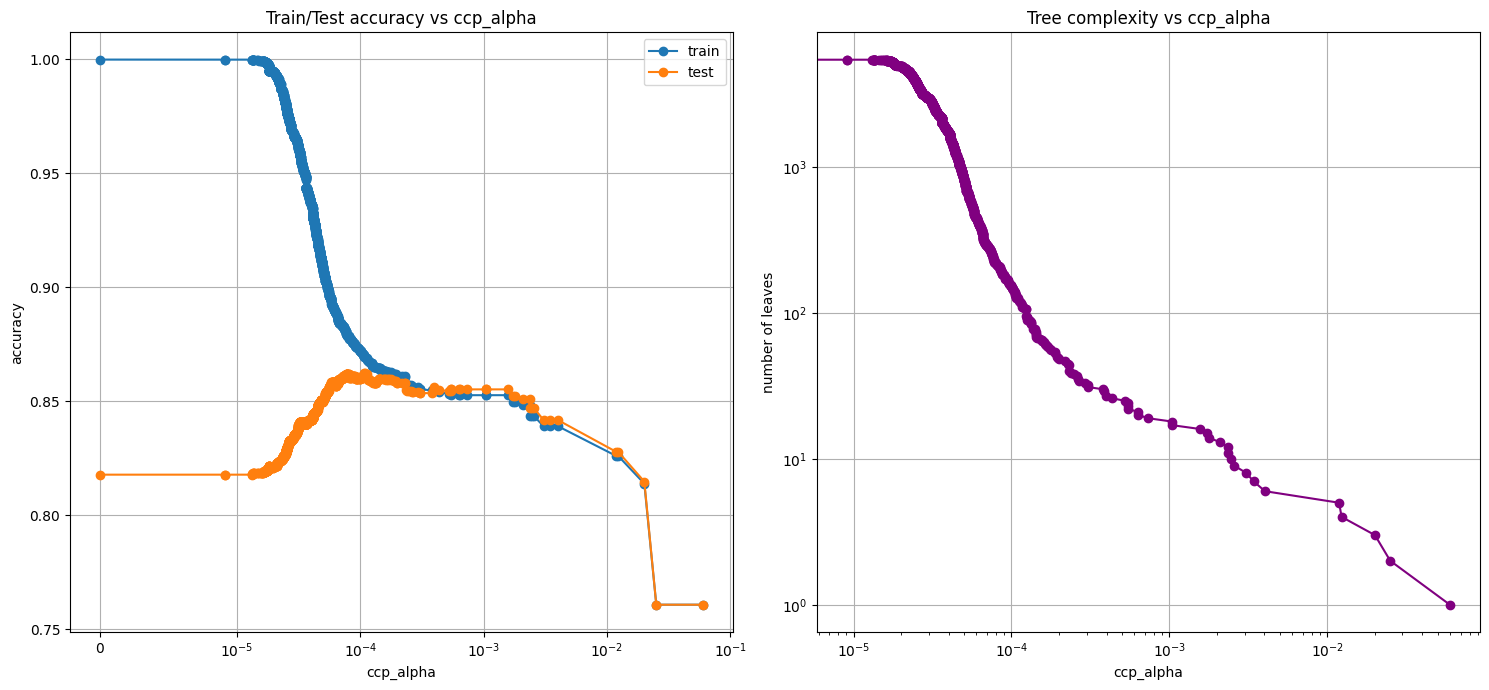

In [32]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15,7))

axes[0].plot(cost_complexity_df['ccp_alpha'],
             cost_complexity_df['train_acc'],
             marker='o', label='train')

axes[0].plot(cost_complexity_df['ccp_alpha'],
             cost_complexity_df['test_acc'],
             marker='o', label='test')

axes[0].set_xlabel('ccp_alpha')
axes[0].set_ylabel('accuracy')
axes[0].set_title('Train/Test accuracy vs ccp_alpha')
axes[0].grid(True)
axes[0].legend()

axes[1].plot(cost_complexity_df['ccp_alpha'],
             cost_complexity_df['n_leaves'],
             marker='o', color='purple')

axes[1].set_xlabel('ccp_alpha')
axes[1].set_ylabel('number of leaves')
axes[1].set_title('Tree complexity vs ccp_alpha')
axes[1].grid(True)

axes[0].set_xscale('symlog', linthresh=1e-5)

axes[1].set_yscale('symlog', linthresh=1e-5)
axes[1].set_xscale('log')

plt.tight_layout()
plt.show()

---

## 6. Wybór optymalnego `ccp_alpha` przez GridSearchCV

### 6.1. Ograniczenie zakresu parametru cpp_alpha

Na podstawie powyższego wykresu ograniczam zakres parametru cpp_alpha do przedziału, w którym train i test accuracy jest najwyższe, w celu zaoszczędzenia czasu podczas wyznaczania optymalnej wartości parametru za pomoca GridSearchCV.

In [12]:
alphas = np.unique(path.ccp_alphas)

start = 10**(-4.2)
end = 1e-3

filtered_alphas = alphas[
    (alphas >= start) & (alphas <= end)
]

print(len(filtered_alphas))

206



### 6.2 Walidacja krzyżowa dla przefiltrowanych alphas

In [13]:
grid_search_cv = GridSearchCV(base_pipe, param_grid={'clf__ccp_alpha':filtered_alphas}, cv=10, n_jobs=-1, return_train_score=True, scoring='accuracy')

grid_search_cv.fit(X_train, y_train)

best_ccp_alpha = grid_search_cv.best_params_['clf__ccp_alpha']
print("Best alpha:", best_ccp_alpha)
print("Best CV score:", grid_search_cv.best_score_)

Best alpha: 0.00019429228746121902
Best CV score: 0.8577707173231192



---

## 7. Porównanie strategii regularyzacji drzewa

### 7.1. Tabela porównawcza modeli

In [14]:
models = {

    'full_tree' : Pipeline([
        ('preproc', preproc),
        ('clf', DecisionTreeClassifier(random_state=seed))
    ]),

    'pruned_tree_max_depth' : Pipeline([
        ('preproc', preproc),
        ('clf', DecisionTreeClassifier(random_state=seed, max_depth=best_max_depth))
    ]),

    'combined_pruned_tree':
    Pipeline([
        ('preproc', preproc),
        ('clf', DecisionTreeClassifier(random_state=seed, max_depth=10, min_samples_leaf=20, min_impurity_decrease=1e-4))
    ]),
    'pruned_tree_cpp_alpha':
    Pipeline([
        ('preproc', preproc),
        ('clf', DecisionTreeClassifier(random_state=seed, ccp_alpha=best_ccp_alpha))
    ]),

}


rows = []
for name, pipe in models.items():

    pipe.fit(X_train, y_train)

    train_acc = pipe.score(X_train, y_train)
    test_acc = pipe.score(X_test, y_test)
    overfit_gap = train_acc - test_acc

    row = {
        'model_name' : name,
        'depth': pipe['clf'].get_depth(),
        'n_leaves': pipe['clf'].get_n_leaves(),
        'train_acc': round(train_acc, 4),
        'test_acc': round(test_acc, 4),
        'f1': round(f1_score(y_test, pipe.predict(X_test)), 4),
        'overfit_gap' : round(overfit_gap, 4)

    }
    rows.append(row)


models_summary_df = pd.DataFrame(rows)

models_summary_df


,model_name,depth,n_leaves,train_acc,test_acc,f1,overfit_gap
0,full_tree,44,5440,0.9999,0.8175,0.6234,0.1824
1,pruned_tree_max_depth,7,87,0.8585,0.8587,0.6526,-0.0003
2,combined_pruned_tree,10,68,0.8589,0.8556,0.6749,0.0033
3,pruned_tree_cpp_alpha,16,50,0.8621,0.8591,0.6793,0.0030


Pełne drzewo wykazuje silne przeuczenie – bardzo wysoki wynik na zbiorze treningowym (0.9999) oraz znacznie niższy wynik testowy (0.8178), co skutkuje dużym overfitting gap (0.1822).

Pre-pruning z ograniczeniem głębokości oraz wersja kombinowana znacząco redukują overfitting, jednak kosztem niewielkiego spadku jakości predykcji (szczególnie F1-score).

Najlepsze wyniki osiąga model z post-pruningiem (ccp_alpha), który uzyskuje najwyższe accuracy na zbiorze testowym (0.8591) oraz najwyższy F1-score (0.6793), przy jednocześnie bardzo małym overfit gap (0.003). Dodatkowo model ten jest najprostszy strukturalnie (najmniejsza liczba liści), co sprzyja lepszej generalizacji.Ponadto paramter cpp_alpha został wyznaczony poprzez przeszukiwanie przestrzeni paramterów a nie ustalony ręcznie. Dlatego właśnie ten model wybrał bym do zastowań produkcyjnych.

---

## 8. Wizualizacja drzewa

In [15]:
tree_depth3 = Pipeline([
        ('preproc', preproc),
        ('clf', DecisionTreeClassifier(random_state=seed, max_depth=3))
    ])

tree_depth3.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preproc', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains 

### 8.1. Wizualizacja przez Graphviz

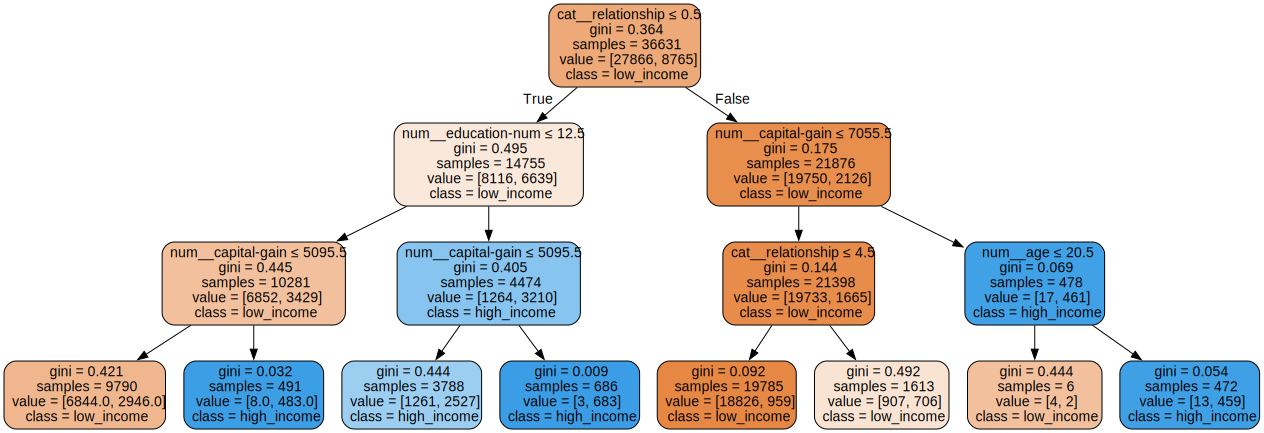

In [22]:
feature_names = tree_depth3.named_steps['preproc'].get_feature_names_out()

dot_data = export_graphviz(
    tree_depth3.named_steps['clf'],
    out_file=None,
    feature_names=feature_names,
    class_names=['low_income', 'high_income'],
    filled=True,
    rounded=True,
    special_characters=True
)

graph = graphviz.Source(dot_data)
graph

### 8.2. Wizualizacja przez dtreeviz

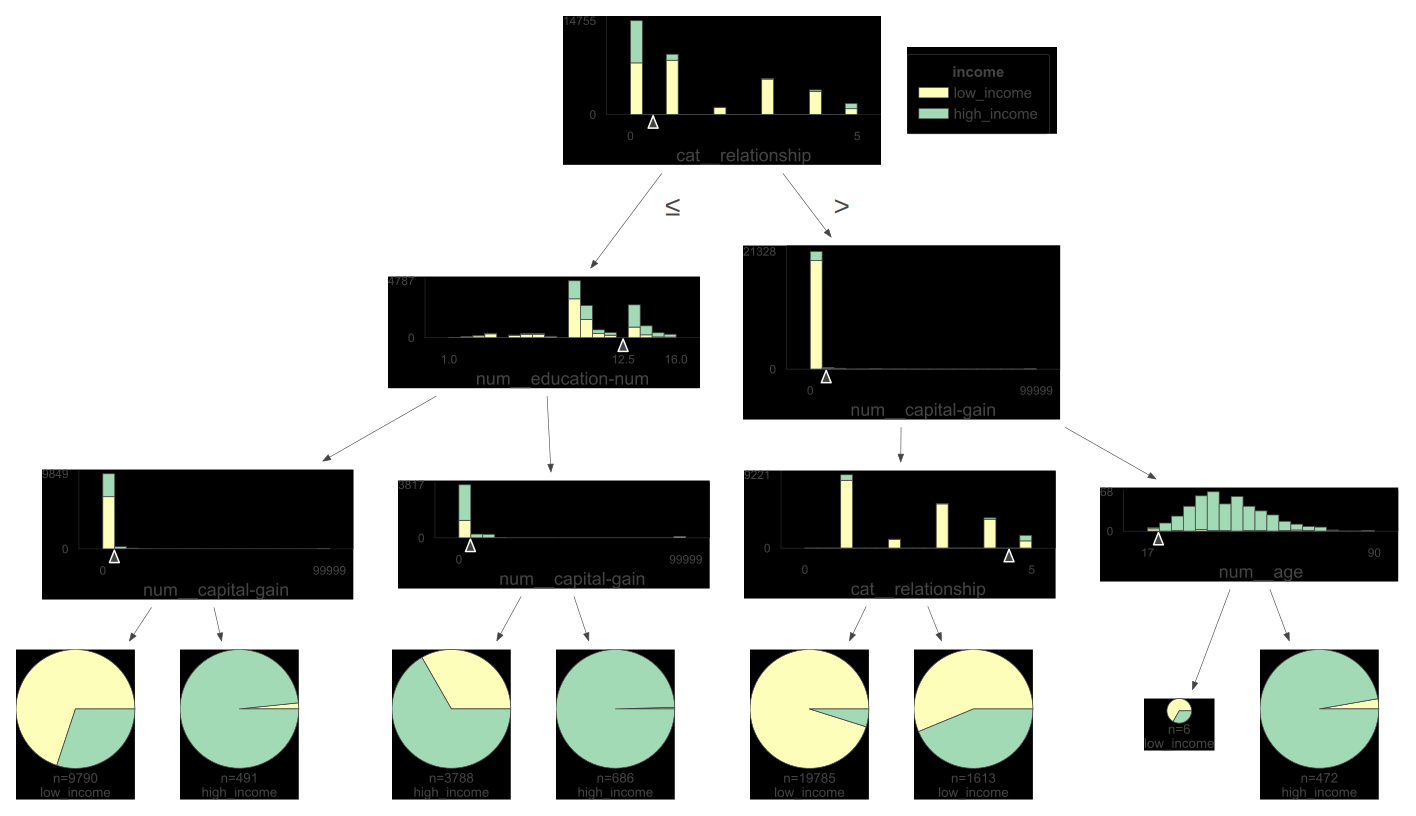

In [23]:
X_train_trans = preproc.fit_transform(X_train)
X_test_trans = preproc.transform(X_test)

viz_rmodel = dtreeviz.model(
    tree_depth3.named_steps['clf'],
    X_train_trans,
    y_train.values,
    feature_names=feature_names,
    class_names=['low_income', 'high_income'],
    target_name='income'
)
viz_rmodel.view(scale=2)

### 8.3. Porównanie reprezentacji

Wizualizacja Graphviz przedstawia strukturę drzewa decyzyjnego w formie hierarchii warunków podziału. Każdy węzeł zawiera regułę decyzyjną oraz informacje o nieczystości i liczbie próbek, co pozwala zrozumieć logikę modelu krok po kroku.

Z kolei dtreeviz rozszerza tę wizualizację o analizę rozkładu danych w każdym węźle. Histogramy pokazują, jak rozkładają się wartości cech przed podziałem, natomiast wykresy kołowe w liściach przedstawiają proporcje klas, co pozwala ocenić pewność predykcji.

---

## 9. Interpretowalność drzewa przyciętego CCP

### 9.1. Built-in oraz Permutation feature importance

In [24]:
pruned_tree_cpp_alpha = models['pruned_tree_cpp_alpha']

pruned_tree_cpp_alpha.fit(X_train, y_train)

model = pruned_tree_cpp_alpha['clf']

feature_names = pruned_tree_cpp_alpha['preproc'].get_feature_names_out()


builtin_importance = model.feature_importances_

builtin_df = pd.DataFrame({
    "feature": feature_names,
    "importance": builtin_importance
}).sort_values("importance", ascending=False)


perm_result = permutation_importance(
    pruned_tree_cpp_alpha,
    X_test,
    y_test,
    n_repeats=10,
    random_state=seed,
    n_jobs=-1
)

perm_df = pd.DataFrame({
    "feature": feature_names,
    "importance": perm_result.importances_mean
}).sort_values("importance", ascending=False)


explainer = shap.Explainer(model, X_train_trans)

X_sample = X_test_trans[:1000]
shap_values = explainer(X_sample)
shap_values.feature_names = feature_names


### 9.2. SHAP summary plot

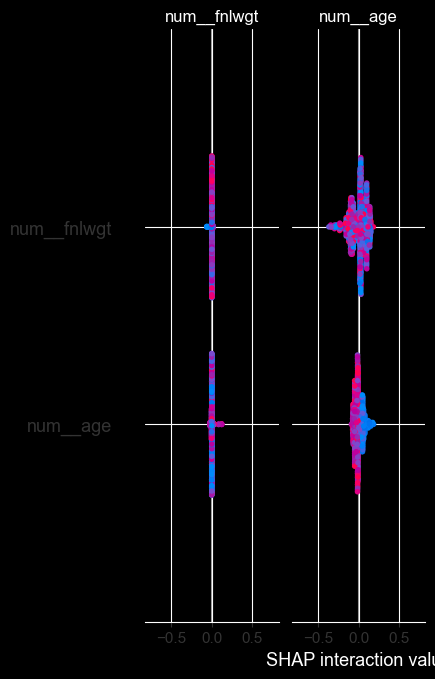

In [25]:
shap.summary_plot(shap_values, X_sample, show=False)


### 9.3. SHAP waterfall plot dla pojedynczej predykcji

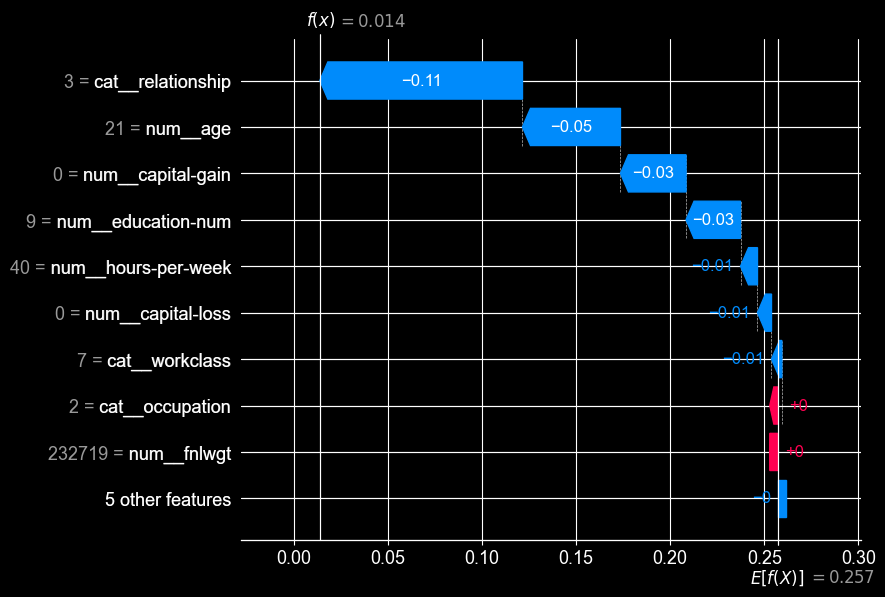

In [26]:
shap.plots.waterfall(shap_values[1, :, 1])

### 9.4 Shap feature importance

In [27]:
shap_df = pd.DataFrame({
    "feature": feature_names,
    "shap_mean": np.abs(shap_values.values[:, :, 1]).mean(axis=0)
}).sort_values("shap_mean", ascending=False)


### 9.5. Porównanie rankingów ważności cech

In [28]:
builtin_df

,feature,importance
10,cat__relationship,0.425673
3,num__capital-gain,0.215224
2,num__education-num,0.213110
4,num__capital-loss,0.062970
0,num__age,0.037014
5,num__hours-per-week,0.030942
6,cat__workclass,0.006864
9,cat__occupation,0.006848
1,num__fnlwgt,0.001356
7,cat__education,0.000000


In [29]:
perm_df

,feature,importance
7,cat__education,0.061215
4,num__capital-loss,0.049799
10,cat__relationship,0.047048
0,num__age,0.016231
11,cat__race,0.008623
12,cat__sex,0.008410
1,num__fnlwgt,0.002522
6,cat__workclass,0.002408
2,num__education-num,0.001654
3,num__capital-gain,0.000000


In [31]:
shap_df

,feature,shap_mean
10,cat__relationship,0.135538
2,num__education-num,0.073137
3,num__capital-gain,0.060036
0,num__age,0.038203
5,num__hours-per-week,0.029347
4,num__capital-loss,0.013068
9,cat__occupation,0.005537
6,cat__workclass,0.003500
1,num__fnlwgt,0.001684
7,cat__education,0.000000


Rankingi ważności cech są częściowo spójne: we wszystkich trzech metodach wysoko pojawia się `cat__relationship`, a cechy takie jak `num__age`, `num__capital-loss` czy `num__education-num `również należą do istotnych predyktorów. Największe różnice widać dla `cat__education,` które w built-in importance i SHAP ma wartość 0, natomiast w permutation importance jest najważniejszą cechą. Może to wynikać z korelacji między cechami, szczególnie między `education` i `education-num`: drzewo mogło bezpośrednio używać jednej z nich w podziałach, ale permutacja drugiej nadal pogarsza wynik modelu, bo zaburza informację powiązaną z poziomem edukacji. Różnice wynikają też z tego, że built-in importance mierzy udział cechy w redukcji impurity w samym drzewie, permutation importance ocenia spadek jakości na zbiorze testowym, a SHAP pokazuje średni wkład cechy w konkretne predykcje, dlatego te metody nie muszą dawać identycznych rankingów.

---

## 10. Fairness audit dla drzewa decyzyjnego

In [23]:
def fairness_metrics(df, group_col):
    results = []

    for group in df[group_col].unique():
        subset = df[df[group_col] == group]

        positive_rate = (subset["y_pred"] == 1).mean()

        tpr = ((subset["y_pred"] == 1) & (subset["y_true"] == 1)).sum() / max((subset["y_true"] == 1).sum(), 1)
        fpr = ((subset["y_pred"] == 1) & (subset["y_true"] == 0)).sum() / max((subset["y_true"] == 0).sum(), 1)

        results.append({
            "group": group,
            "positive_rate": positive_rate,
            "TPR": tpr,
            "FPR": fpr
        })

    return pd.DataFrame(results)

In [28]:
model = models['pruned_tree_cpp_alpha']

model.fit(X_train, y_train)

df_eval = X_test.copy()
df_eval["y_true"] = y_test
df_eval["y_pred"] = model.predict(X_test)


### 10.1. Analiza względem zmiennej `sex`

In [31]:
fair_sex = fairness_metrics(df_eval, "sex")

fair_sex


,group,positive_rate,TPR,FPR
0,Male,0.248321,0.625759,0.085345
1,Female,0.102386,0.613687,0.037525


### 10.2. Analiza względem zmiennej `race`

In [33]:
fair_race = fairness_metrics(df_eval, "race")
fair_race

,group,positive_rate,TPR,FPR
0,White,0.210688,0.625616,0.069326
1,Black,0.109272,0.605263,0.037879
2,Asian-Pac-Islander,0.259542,0.637255,0.127148
3,Other,0.102804,0.545455,0.052083
4,Amer-Indian-Eskimo,0.101695,0.500000,0.030000


### 10.3. Wnioski z audytu fairness - demographic parity oraz equalized odds

Model nie spełnia kryterium demographic parity, ponieważ odsetek pozytywnych predykcji różni się istotnie między grupami zarówno ze względu na płeć (ok. 0.25 dla mężczyzn vs 0.10 dla kobiet), jak i rasę (zakres od ok. 0.10 do 0.26).

Dodatkowo model nie spełnia kryterium equalized odds. Choć wartości TPR są względnie zbliżone między grupami, występują istotne różnice w FPR. W szczególności model generuje znacznie więcej fałszywie pozytywnych predykcji dla niektórych grup (np. Asian-Pac-Islander) niż dla innych (np. Amer-Indian-Eskimo).

Wyniki wskazują na obecność biasu modelu względem cech takich jak płeć czy rasa.


---

# Część II: Random Forest

In [32]:
X_train_transformed = preproc.fit_transform(X_train)
X_test_transformed = preproc.transform(X_test)

## 1. Zbieżność Random Forest względem liczby drzew

### 1.1. Trenowanie Random Forest z `warm_start=True`

In [33]:
n_estimators = [10, 20, 50, 100, 200, 300, 500]

rf_clf = RandomForestClassifier(
    random_state=seed,
    warm_start=True,
    oob_score=True,
    n_jobs=-1
)

test_accuracies = []
oob_scores = []

for n in n_estimators:

    rf_clf.n_estimators=n
    rf_clf.fit(X_train_transformed, y_train)
    y_pred = rf_clf.predict(X_test_transformed)
    test_accuracies.append(accuracy_score(y_test, y_pred))
    oob_scores.append(rf_clf.oob_score_)

/Users/dominik/Desktop/AGH_STUDIES/data-exploration-course/.venv/lib/python3.14/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
/Users/dominik/Desktop/AGH_STUDIES/data-exploration-course/.venv/lib/python3.14/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.


### 1.2. Krzywa zbieżności

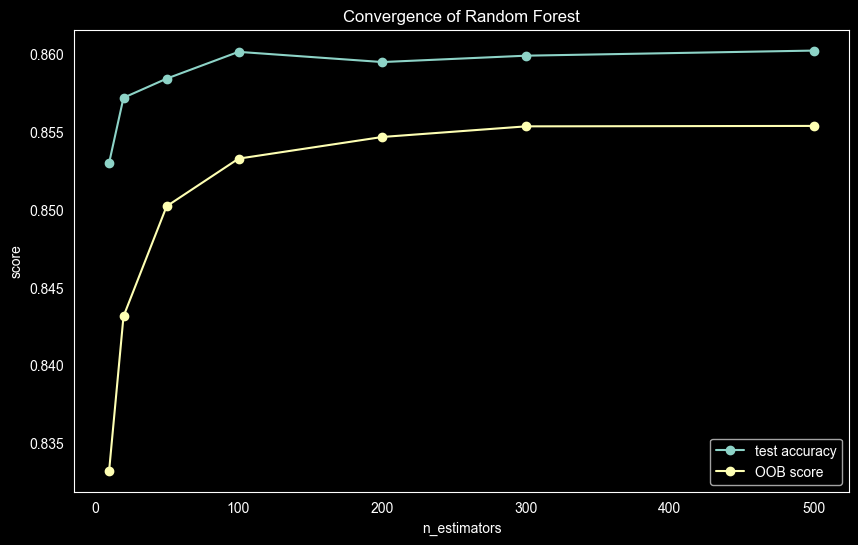

In [34]:
plt.figure(figsize=(10,6))

plt.plot(n_estimators, test_accuracies, marker='o', label='test accuracy')
plt.plot(n_estimators, oob_scores, marker='o', label='OOB score')

plt.xlabel("n_estimators")
plt.ylabel("score")
plt.title("Convergence of Random Forest")
plt.legend()
plt.grid()
plt.show()
plt.show()

Model RandomForest osiga stabilizację dla około 300 drzew. Dalsze zwiększanie liczby drzew nie poprawia wyników, co wskazuje na zbieżność modelu.

---

## 2. Wpływ parametru `max_features`


### 2.1. Eksperyment dla różnych wartości `max_features`

In [35]:
max_features = [1, 2, 4, 'sqrt', 'log2', 0.5, None]

rows = []

for max_feature in max_features:

    rf_clf = RandomForestClassifier(
        n_estimators=200,
        max_features=max_feature,
        random_state=seed,
        oob_score=True,
        n_jobs=-1
    )

    rf_clf.fit(X_train_transformed, y_train)
    y_pred = rf_clf.predict(X_test_transformed)
    row = {
        'max_features': max_feature,
        'test_acc': accuracy_score(y_test, y_pred),
        'oob_score': rf_clf.oob_score_
    }

    rows.append(row)


info_df = pd.DataFrame(rows)

info_df

,max_features,test_acc,oob_score
0,1,0.857669,0.853266
1,2,0.859389,0.853403
2,4,0.858570,0.854413
3,sqrt,0.859471,0.854659
4,log2,0.859471,0.854659
5,0.5,0.858898,0.853922
6,None,0.857751,0.851465


### 2.2. Kompromis bias-variance dla `max_features`

Najlepszy kompromis uzyskano dla `max_features = 2`, `sqrt` oraz `log2`, które dają najwyższe accuracy (~0.86) i wysokie OOB score. Zbyt małe wartości zwiększają bias (zbyt proste drzewa), natomiast zbyt duże zmniejszają różnorodność drzew, co pogarsza generalizację modelu

---

## 3. Optymalizacja hiperparametrów Random Forest przez Optuna

### 3.1. Definicja przestrzeni hiperparametrów

In [38]:
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 500, step=50),
        "max_depth": trial.suggest_int("max_depth", 3, 30),
        "max_features": trial.suggest_categorical(
            "max_features", ["sqrt", "log2", 0.3, 0.5, 0.8]
        ),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 20),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 30),
    }

    rf = RandomForestClassifier(**params, random_state=seed, n_jobs=-1)

    score = cross_val_score(
        rf,
        X_train_transformed,
        y_train,
        cv=5,
        scoring="balanced_accuracy"
    ).mean()

    return score


study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=seed)
)

study.optimize(objective, n_trials=25)

[I 2026-04-29 19:32:26,394] A new study created in memory with name: no-name-5cf099b0-81e4-4ea9-8736-ddb2c91456f9
[I 2026-04-29 19:32:27,713] Trial 0 finished with value: 0.7649529143579362 and parameters: {'n_estimators': 200, 'max_depth': 29, 'max_features': 'sqrt', 'min_samples_leaf': 18, 'min_samples_split': 19}. Best is trial 0 with value: 0.7649529143579362.
[I 2026-04-29 19:32:29,553] Trial 1 finished with value: 0.6621564180216218 and parameters: {'n_estimators': 400, 'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 7, 'min_samples_split': 17}. Best is trial 0 with value: 0.7649529143579362.
[I 2026-04-29 19:32:31,029] Trial 2 finished with value: 0.7553962638648992 and parameters: {'n_estimators': 250, 'max_depth': 11, 'max_features': 'sqrt', 'min_samples_leaf': 16, 'min_samples_split': 7}. Best is trial 0 with value: 0.7649529143579362.
[I 2026-04-29 19:32:34,874] Trial 3 finished with value: 0.7726224679531799 and parameters: {'n_estimators': 300, 'max_depth': 19,

### 3.2. Wyniki optymalizacji

In [39]:
print(study.best_params)

{'n_estimators': 100, 'max_depth': 30, 'max_features': 0.3, 'min_samples_leaf': 3, 'min_samples_split': 20}


---

## 4. Porównanie modeli: Decision Tree, Random Forest i HistGradientBoosting

### 4.1 Budowa tabeli porównawczej modeli test_acc i f1_score

In [40]:
models_v2 = {
    "decision_tree_ccp": DecisionTreeClassifier(random_state=seed, ccp_alpha=best_ccp_alpha),

    "rf_optuna_clf": RandomForestClassifier(**study.best_params, random_state=seed, n_jobs=-1),

    "hist_boost_clf" : HistGradientBoostingClassifier(max_iter=300, random_state=seed)
}

rows = []

for name, model in models_v2.items():

    model.fit(X_train_transformed, y_train)
    y_pred = model.predict(X_test_transformed)

    row = {
        'model' : name,
        'test_acc': accuracy_score(y_test, y_pred),
        'f1_score': f1_score(y_test, y_pred, average='weighted'),
    }

    rows.append(row)


models_comparison_df = pd.DataFrame(rows)

models_comparison_df

,model,test_acc,f1_score
0,decision_tree_ccp,0.859062,0.854562
1,rf_optuna_clf,0.867906,0.862124
2,hist_boost_clf,0.876669,0.872363


### 4.2. Zysk jakości a koszt złożoności modelu

Najlepsze wyniki osiąga HistGradientBoostingClassifier (accuracy 0.877, F1 0.872), przewyższając zarówno zoptymalizowany Random Forest (0.867 / 0.861), jak i Decision Tree z przycinaniem CCP (0.859 / 0.855).

Oznacza to, że boosting lepiej uchwycił złożone zależności w danych niż metody oparte na pojedynczych drzewach lub ich baggingu.

Poprawa jakości odbywa się jednak kosztem:

 - większej złożoności modelu,
 - mniejszej interpretowalności w porównaniu do pojedynczego drzewa.

Random Forest stanowi kompromis między jakością a stabilnością, natomiast Decision Tree jest najsłabszy, ale najprostszy i najbardziej interpretowalny

---

## 5. Interpretowalność Random Forest

### 5.1. Built-in feature importance oraz permutation importance

In [41]:
rf_optuna_clf = models_v2['rf_optuna_clf']


builtin_importance = rf_optuna_clf.feature_importances_

builtin_df = pd.DataFrame({
    "feature": feature_names,
    "importance": builtin_importance
}).sort_values("importance", ascending=False)


perm_result = permutation_importance(
    rf_optuna_clf,
    X_test_transformed,
    y_test,
    n_repeats=10,
    random_state=seed,
    n_jobs=-1
)

perm_df = pd.DataFrame({
    "feature": feature_names,
    "importance": perm_result.importances_mean
}).sort_values("importance", ascending=False)


explainer = shap.Explainer(rf_optuna_clf, X_train_transformed)

X_sample =  X_train_transformed[:1000]
shap_values = explainer(X_sample)
shap_values.feature_names = feature_names

100%|===================| 1990/2000 [00:48<00:00]        

### 5.3. SHAP summary plot


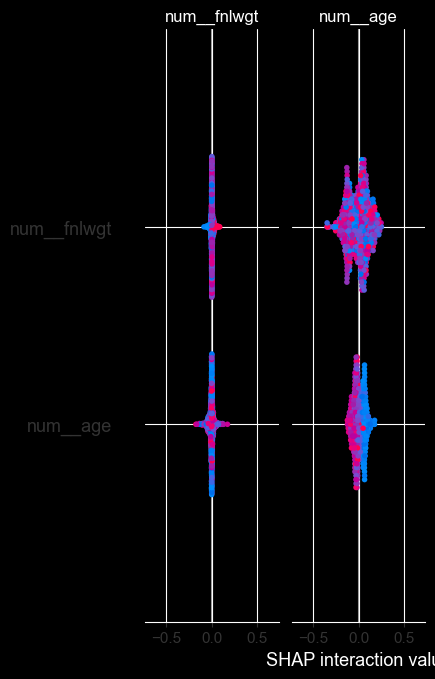

In [43]:
shap.summary_plot(shap_values, X_sample, show=False)

### 5.4. SHAP waterfall plot dla pojedynczej predykcji

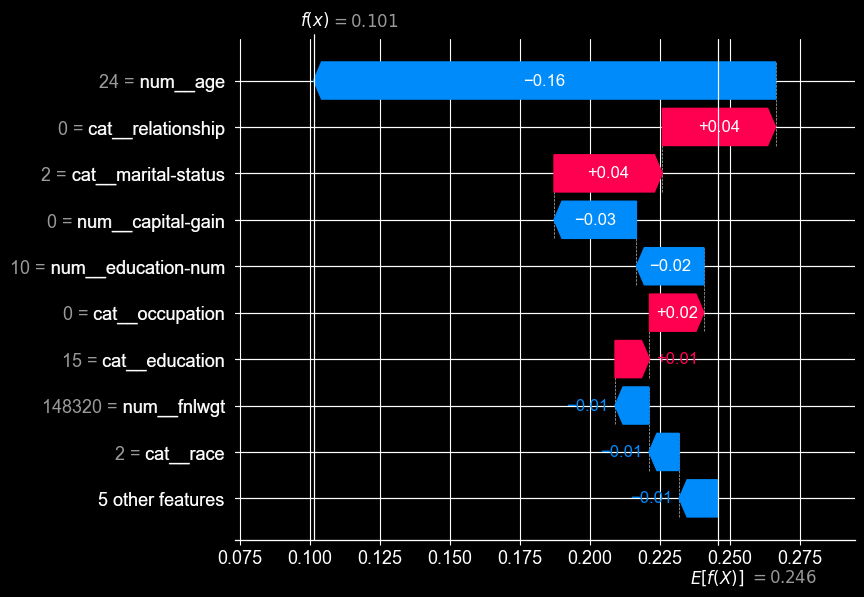

In [44]:
shap.plots.waterfall(shap_values[1, :, 1])

### 5.4. Shap feature importance

In [45]:
shap_df = pd.DataFrame({
    "feature": feature_names,
    "shap_mean": np.abs(shap_values.values[:, :, 1]).mean(axis=0)
}).sort_values("shap_mean", ascending=False)


### 5.5. Porównanie rankingów cech z pojedynczym drzewem

In [46]:
builtin_df

,feature,importance
3,num__capital-gain,0.179460
10,cat__relationship,0.170771
2,num__education-num,0.128368
8,cat__marital-status,0.105610
0,num__age,0.098317
1,num__fnlwgt,0.070843
5,num__hours-per-week,0.066057
4,num__capital-loss,0.049935
9,cat__occupation,0.042256
7,cat__education,0.037075


In [47]:
perm_df

,feature,importance
3,num__capital-gain,0.047392
2,num__education-num,0.031570
10,cat__relationship,0.028474
0,num__age,0.017492
4,num__capital-loss,0.010327
9,cat__occupation,0.009999
5,num__hours-per-week,0.009532
8,cat__marital-status,0.009254
6,cat__workclass,0.003284
7,cat__education,0.002137


In [48]:
shap_df

,feature,shap_mean
10,cat__relationship,0.068499
2,num__education-num,0.062436
3,num__capital-gain,0.055039
8,cat__marital-status,0.053899
0,num__age,0.046757
5,num__hours-per-week,0.031174
9,cat__occupation,0.019751
4,num__capital-loss,0.013905
7,cat__education,0.012541
1,num__fnlwgt,0.008698


W przypadku Random Forest rankingi cech są bardziej stabilne i mniej „zero-jedynkowe” niż dla pojedynczego drzewa przyciętego CCP — większość cech otrzymuje niezerową ważność, ponieważ las korzysta z wielu różnych podziałów w wielu drzewach. Najważniejsze pozostają podobne zmienne jak wcześniej, zwłaszcza `cat__relationship`, `num__education-num`, `num__capital-gain`, `num__age` oraz `cat__marital-status`, ale ich kolejność zależy od metody liczenia ważności. W porównaniu z pojedynczym drzewem większe znaczenie zyskują m.in. `cat__marital-status`, `num__fnlwgt`, `cat__occupation` i `cat__education`, ponieważ Random Forest może wykorzystywać cechy, które w pojedynczym drzewie nie zostały wybrane do podziałów. Różnice między built-in, permutation importance i SHAP wynikają z tego, że built-in mierzy średnią redukcję impurity w drzewach, permutation importance ocenia spadek jakości predykcji po zaburzeniu cechy na zbiorze testowym, a SHAP opisuje średni wkład cechy w pojedyncze predykcje

---

# Część III: Klasyfikator k-NN

## 1. Zbiór Palmer Penguins

### 1.1. Wczytanie i czyszczenie danych

In [2]:
dataset_name = 'Palmer Penguins'
target_col = 'species'
penguins = fetch_openml('penguins', as_frame=True, version=1)
penguins_df = penguins.frame.copy()


print(f'Wczytano {dataset_name}: {penguins_df.shape}')
print(f'Rozkład klas {penguins_df[target_col].value_counts().to_dict()} ')
penguins_df.head(10)

Wczytano Palmer Penguins: (344, 7)
Rozkład klas {'Adelie': 152, 'Gentoo': 124, 'Chinstrap': 68} 


,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE
6,Adelie,Torgersen,38.9,17.8,181.0,3625.0,FEMALE
7,Adelie,Torgersen,39.2,19.6,195.0,4675.0,MALE
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN


In [3]:
penguins_info = pd.DataFrame(
      {
            'dtypes': penguins_df.dtypes.astype(str),
            'missing': penguins_df.isnull().sum(),
            "missing %": (penguins_df.isnull().sum() / len(penguins_df) * 100).round(2),
            "nunique": penguins_df.nunique()
      }
)
penguins_info

,dtypes,missing,missing %,nunique
species,category,0,0.00,3
island,category,0,0.00,3
culmen_length_mm,float64,2,0.58,164
culmen_depth_mm,float64,2,0.58,80
flipper_length_mm,float64,2,0.58,55
body_mass_g,float64,2,0.58,94
sex,category,10,2.91,3


In [4]:
penguins_df = penguins_df.dropna()

In [6]:
num_cols = penguins_df.select_dtypes(include=[np.float64]).columns.tolist()
cat_cols = penguins_df.select_dtypes(include=['category']).columns.drop(target_col).tolist()
print(f'Numeric: ({len(num_cols)}): {num_cols}')
print(f'Categorical: ({len(cat_cols)}): {cat_cols}')

Numeric: (4): ['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g']
Categorical: (2): ['island', 'sex']


### 1.2. Preprocessing: imputacja, skalowanie i kodowanie cech

In [56]:
numerical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy='median')),
    ("scaler", StandardScaler())
])


categorical_transformer = Pipeline(steps =[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

columns_transformer =  ColumnTransformer(
    [
        ("num_cols", numerical_transformer, num_cols),
        ("cat_cols", categorical_transformer, cat_cols)
    ],
    remainder='drop',
)


penguins_feature_names = num_cols + cat_cols

X = penguins_df.drop(columns=target_col)
y = penguins_df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
      X, y, test_size=0.25, stratify=y, random_state=seed
)

penguins_model = Pipeline(steps=[
    ("preprocess", columns_transformer),
    ("knn", KNeighborsClassifier())
])

print(f'Trening: {X_train.shape} Test: {X_test.shape}')
print(f'Rozkład klas (trening): {pd.Series(y_train).value_counts(normalize=True).round(3).to_dict()}')

Trening: (250, 6) Test: (84, 6)
Rozkład klas (trening): {'Adelie': 0.436, 'Gentoo': 0.36, 'Chinstrap': 0.204}


### 1.3. Uzasadnienie skalowania dla k-NN

Dla k-NN musimy zastosować skalowania danych numerycznych, gdyż w przeciwnym przypadku, mogła by wystąpić sytuacja, że cecha o największej skali zdominuje metrykę.

---

## 2. Dobór hiperparametrów k-NN

### 2.1. GridSearchCV dla liczby sąsiadów, metryki i wag

In [15]:
params = {
    'knn__n_neighbors': [1, 3, 5, 7, 9, 11, 15],
    'knn__metric' : ['euclidean', 'manhattan', 'chebyshev'],
    'knn__weights': ['uniform', 'distance']
}

penguins_grid_cv = GridSearchCV(
    estimator=penguins_model,
    cv=5,
    scoring='accuracy',
    param_grid=params,
    refit=True,
    n_jobs=-1,
)
penguins_grid_cv.fit(X_train, y_train)

print(f'Best params: {penguins_grid_cv.best_params_}')
print(f'Best score: {penguins_grid_cv.best_score_:.4f}')

Best params: {'knn__metric': 'euclidean', 'knn__n_neighbors': 1, 'knn__weights': 'uniform'}
Best score: 0.9960


### 2.2. Heatmapa wyników walidacji krzyżowej

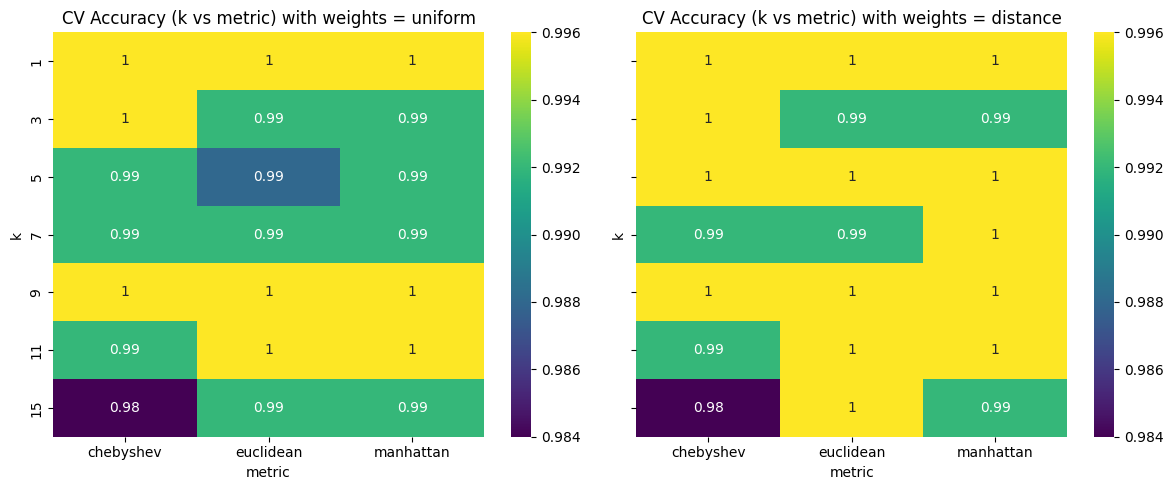

In [25]:
results = pd.DataFrame(penguins_grid_cv.cv_results_)
weights_values = ["uniform", "distance"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, w in zip(axes, weights_values):
    subset = results[results["param_knn__weights"] == w]

    pivot = subset.pivot_table(
        values="mean_test_score",
        index="param_knn__n_neighbors",
        columns="param_knn__metric"
    )

    sns.heatmap(pivot, annot=True, cmap="viridis", ax=ax)
    ax.set_title(f"CV Accuracy (k vs metric) with weights = {w}")
    ax.set_xlabel("metric")
    ax.set_ylabel("k")

plt.tight_layout()
plt.show()

---

## 3. k-NN dla zbioru NYT-frame po PCA

### 3.1 Wczytanie i preprocessing danych

In [37]:
nyt_df = pd.read_csv('datasets/nyt-frame.csv', header = 0, index_col=0)
print(f'Wyczytano NYT Frame: {nyt_df.shape}')
nyt_df.head()

Wyczytano NYT Frame: (102, 4432)


,class.labels,X.,X.d,X.nd,X.s,X.th,X.this,a,abandoned,abc,...,yorkers,yorks,you,young,younger,your,youre,youth,youthful,yu
1,art,0.008707,0.0,0.0,0.000000,0.009251,0.0,0.007564,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,art,0.005848,0.0,0.0,0.000000,0.000000,0.0,0.001418,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,art,0.016036,0.0,0.0,0.011403,0.000000,0.0,0.010063,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,art,0.026415,0.0,0.0,0.000000,0.000000,0.0,0.008677,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,art,0.007285,0.0,0.0,0.011008,0.000000,0.0,0.008390,0.0,0.0,...,0.0,0.0,0.048151,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [49]:
nyt_info = pd.DataFrame(
      {
            'dtypes': nyt_df.dtypes.astype(str),
            'missing': nyt_df.isnull().sum(),
            "missing %": (nyt_df.isnull().sum() / len(nyt_df) * 100).round(2),
            "nunique": nyt_df.nunique()
      }
)
nyt_info

,dtypes,missing,missing %,nunique
class.labels,str,0,0.0,2
X.,float64,0,0.0,95
X.d,float64,0,0.0,9
X.nd,float64,0,0.0,4
X.s,float64,0,0.0,39
...,...,...,...,...
your,float64,0,0.0,11
youre,float64,0,0.0,7
youth,float64,0,0.0,3
youthful,float64,0,0.0,3


In [44]:
X_nyt =  nyt_df.drop(columns=['class.labels'])
y_nyt = nyt_df['class.labels']

### 3.2. GridSearchCV dla liczby sąsiadów, metryki i wag

In [51]:
model_high = Pipeline([
    ('knn', KNeighborsClassifier())
])


nyt_grid_high = GridSearchCV(
    estimator=model_high,
    param_grid=params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

nyt_grid_high.fit(X_nyt, y_nyt)

print("HIGH-D best score:", nyt_grid_high.best_score_)
print("HIGH-D best params:", nyt_grid_high.best_params_)

HIGH-D best score: 0.8623809523809524
HIGH-D best params: {'knn__metric': 'euclidean', 'knn__n_neighbors': 11, 'knn__weights': 'uniform'}


## 3.3. Heatmapa wyników walidacji krzyżowej

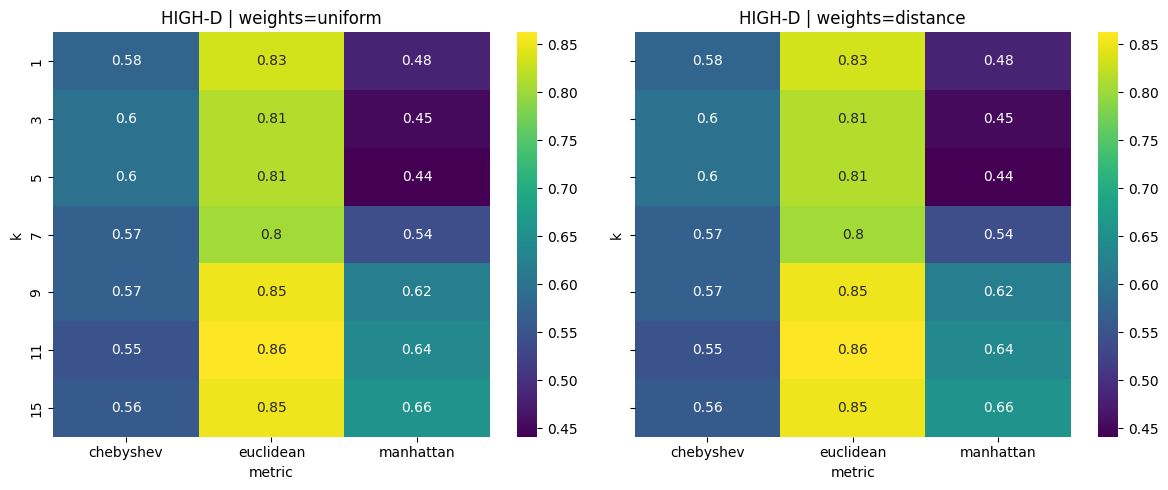

In [52]:
results_high = pd.DataFrame(nyt_grid_high.cv_results_)
weights_values = ["uniform", "distance"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, w in zip(axes, weights_values):
    subset = results_high[results_high["param_knn__weights"] == w]

    pivot = subset.pivot_table(
        values="mean_test_score",
        index="param_knn__n_neighbors",
        columns="param_knn__metric"
    )

    sns.heatmap(pivot, annot=True, cmap="viridis", ax=ax)
    ax.set_title(f"HIGH-D | weights={w}")
    ax.set_xlabel("metric")
    ax.set_ylabel("k")

plt.tight_layout()
plt.show()

### 3.4. GridSearchCV dla liczby sąsiadów, metryki i wag dla zbioru po redukcji wymiarowści z PCA(10)

In [53]:
model_pca = Pipeline([
    ('pca', PCA(n_components=10)),
    ('knn', KNeighborsClassifier())
])

nyt_grid_pca = GridSearchCV(
    estimator=model_pca,
    param_grid=params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

nyt_grid_pca.fit(X_nyt, y_nyt)

print("PCA best score:", nyt_grid_pca.best_score_)
print("PCA best params:", nyt_grid_pca.best_params_)

PCA best score: 0.7661904761904761
PCA best params: {'knn__metric': 'chebyshev', 'knn__n_neighbors': 9, 'knn__weights': 'uniform'}


## 3.5. Heatmapa wyników walidacji krzyżowej

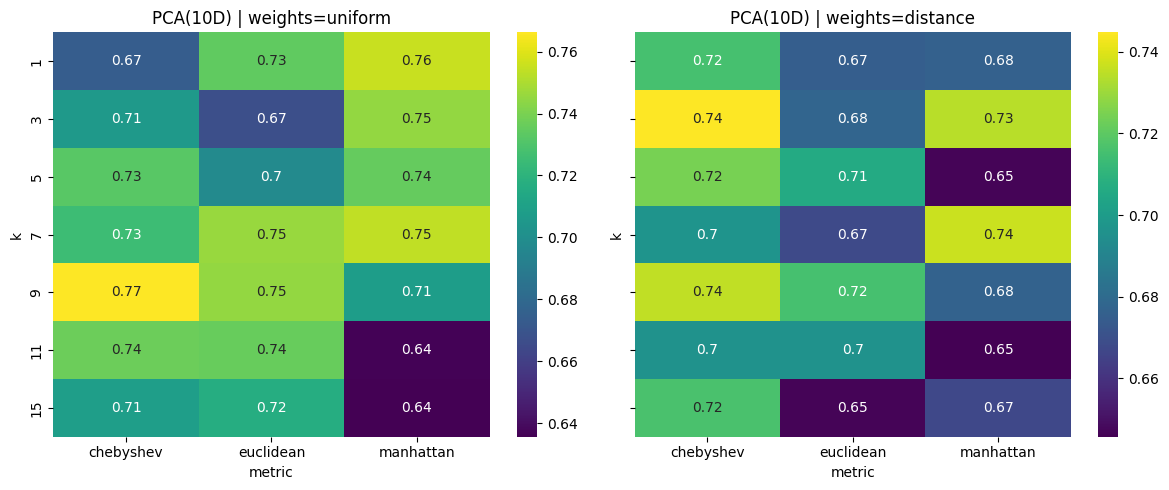

In [54]:
results_pca = pd.DataFrame(nyt_grid_pca.cv_results_)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, w in zip(axes, weights_values):
    subset = results_pca[results_pca["param_knn__weights"] == w]

    pivot = subset.pivot_table(
        values="mean_test_score",
        index="param_knn__n_neighbors",
        columns="param_knn__metric"
    )

    sns.heatmap(pivot, annot=True, cmap="viridis", ax=ax)
    ax.set_title(f"PCA(10D) | weights={w}")
    ax.set_xlabel("metric")
    ax.set_ylabel("k")

plt.tight_layout()
plt.show()

## 3.6. Porównanie wyników dla pełnego i zredukowanego datasetu

In [55]:
print("\n=== COMPARISON ===")
print("HIGH-D best score:", nyt_grid_high.best_score_)
print("PCA 10D best score:", nyt_grid_pca.best_score_)


=== COMPARISON ===
HIGH-D best score: 0.8623809523809524
PCA 10D best score: 0.7661904761904761


Dla pełnowymiarowego zbioru danych najlepszą skuteczność klasyfikacji uzyskano przy zastosowaniu metryki euklidesowej. Po redukcji wymiarowości do 10 komponentów za pomocą PCA najbardziej efektywną okazała się metryka Czebyszewa. Zmiana ta wynika z faktu, że redukcja wymiarów zmniejsza zjawisko koncentracji odległości, przez co różne metryki zaczynają inaczej odwzorowywać strukturę danych. W przestrzeni niskowymiarowej metryka Czebyszewa może lepiej wychwytywać dominujące różnice w pojedynczych wymiarach

---

## 4. Optymalizacja bayesowska k-NN

### 4.1. Przestrzeń hiperparametrów

In [60]:
def objective(trial):

    param_space = {
        "n_neighbors": trial.suggest_int("n_neighbors", 1, 20, step=1),
        "metric": trial.suggest_categorical("metric", ['euclidean', 'manhattan','cosine']),
        "weights": trial.suggest_categorical("weights", ['uniform', 'distance'] )

    }

    knn = KNeighborsClassifier(**param_space, n_jobs=-1)

    score = cross_val_score(
        knn,
        X_nyt,
        y_nyt,
        cv=5,
        scoring="balanced_accuracy"
    ).mean()

    return score


study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=seed)
)

study.optimize(objective, n_trials=25)

[I 2026-04-28 22:10:06,592] A new study created in memory with name: no-name-db0fe7bb-eeb7-4349-975e-1396a504be0f
[I 2026-04-28 22:10:09,423] Trial 0 finished with value: 0.8032828282828284 and parameters: {'n_neighbors': 8, 'metric': 'euclidean', 'weights': 'uniform'}. Best is trial 0 with value: 0.8032828282828284.
[I 2026-04-28 22:10:10,441] Trial 1 finished with value: 0.83510101010101 and parameters: {'n_neighbors': 2, 'metric': 'euclidean', 'weights': 'distance'}. Best is trial 1 with value: 0.83510101010101.
[I 2026-04-28 22:10:11,700] Trial 2 finished with value: 0.85 and parameters: {'n_neighbors': 17, 'metric': 'euclidean', 'weights': 'distance'}. Best is trial 2 with value: 0.85.
[I 2026-04-28 22:10:12,793] Trial 3 finished with value: 0.6613636363636364 and parameters: {'n_neighbors': 9, 'metric': 'manhattan', 'weights': 'distance'}. Best is trial 2 with value: 0.85.
[I 2026-04-28 22:10:13,806] Trial 4 finished with value: 0.8366161616161616 and parameters: {'n_neighbors': 

### 4.2. Wyniki optymalizacji

In [65]:
print(f'Optuna best params: {study.best_params}')
print(f'GridSearchCV best params: {nyt_grid_high.best_params_}')

Optuna best params: {'n_neighbors': 18, 'metric': 'euclidean', 'weights': 'distance'}
GridSearchCV best params: {'knn__metric': 'euclidean', 'knn__n_neighbors': 11, 'knn__weights': 'uniform'}


### 4.3 Porówananie optymalizacji Optuna z GridSearchCV

In [64]:
best_knn = KNeighborsClassifier(**study.best_params, n_jobs=-1)

optuna_score = cross_val_score(
    best_knn,
    X_nyt,
    y_nyt,
    cv=5,
    scoring="balanced_accuracy"
).mean()

print("Optuna score:", optuna_score)
print("GridSearch score:", nyt_grid_high.best_score_)

Optuna score: 0.8631313131313132
GridSearch score: 0.8623809523809524


Optymalizacja bayesowska przy użyciu Optuna pozwoliła uzyskać wynik bardzo zbliżony do GridSearchCV (0.8631 vs 0.8624). Różnica jest minimalna, co sugeruje, że w przypadku danych wysokowymiarowych (NYT) przestrzeń hiperparametrów nie ma dużego wpływu na końcową jakość modelu k-NN.